In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data = pd.read_csv("TOTF_trade_2014_2017.csv")
Data = Data.drop(columns='source_file')
years = ['2014', '2015', '2016', '2017']
years_data = {}
for year in years :
    years_data[year] = Data[Data['date'].str.contains(year)]
print(years_data['2017'])

               date      time  trade.price  trade.volume
4942176  2017-01-02  09:30:13    48.655000          90.0
4942177  2017-01-02  09:30:29    48.658971         170.0
4942178  2017-01-02  09:30:29    48.670000         535.0
4942179  2017-01-02  09:30:29    48.695000         400.0
4942180  2017-01-02  09:30:30    48.690000         103.0
...             ...       ...          ...           ...
5324781  2017-04-12  15:36:19    48.640000        2000.0
5324782  2017-04-12  15:36:19    48.640000         800.0
5324783  2017-04-12  15:36:19    48.640000         300.0
5324784  2017-04-12  15:36:20    48.640000         400.0
5324785  2017-04-12  15:36:34    48.640000          50.0

[382610 rows x 4 columns]


---
# **U-shape intraday**
---

In [7]:
times = []
for hour in range(9, 16):
    if hour == 9:
        minutes_range = range(30, 60)
    elif hour == 15:
        minutes_range = range(0, 37)
    else:
        minutes_range = range(0, 60)
    
    for minute in minutes_range:
        times.append(f'{hour}:{minute:02d}')
print (times)

['9:30', '9:31', '9:32', '9:33', '9:34', '9:35', '9:36', '9:37', '9:38', '9:39', '9:40', '9:41', '9:42', '9:43', '9:44', '9:45', '9:46', '9:47', '9:48', '9:49', '9:50', '9:51', '9:52', '9:53', '9:54', '9:55', '9:56', '9:57', '9:58', '9:59', '10:00', '10:01', '10:02', '10:03', '10:04', '10:05', '10:06', '10:07', '10:08', '10:09', '10:10', '10:11', '10:12', '10:13', '10:14', '10:15', '10:16', '10:17', '10:18', '10:19', '10:20', '10:21', '10:22', '10:23', '10:24', '10:25', '10:26', '10:27', '10:28', '10:29', '10:30', '10:31', '10:32', '10:33', '10:34', '10:35', '10:36', '10:37', '10:38', '10:39', '10:40', '10:41', '10:42', '10:43', '10:44', '10:45', '10:46', '10:47', '10:48', '10:49', '10:50', '10:51', '10:52', '10:53', '10:54', '10:55', '10:56', '10:57', '10:58', '10:59', '11:00', '11:01', '11:02', '11:03', '11:04', '11:05', '11:06', '11:07', '11:08', '11:09', '11:10', '11:11', '11:12', '11:13', '11:14', '11:15', '11:16', '11:17', '11:18', '11:19', '11:20', '11:21', '11:22', '11:23', '11

In [8]:
def avg_over_year_all_days_timeT(data, time, vtype='trade.volume'):
    values = data[data['time'].str.contains(time)]
    dates = values['date'].unique()
    sums = [values[values['date'] == date][vtype].sum() for date in dates]
    return np.mean(sums)

In [9]:
def avg_over_year_all_days_all_times(data, times, vtype='trade.volume'):
    results = []
    for time in times:
        results.append(avg_over_year_all_days_timeT(data, time, vtype))
    return results

### Analysis of Your Current Code
**Your approach is generally correct.**

#### Time interval handling: 
You're correctly creating minute-by-minute time intervals from 9:30 to 15:36.

#### Calculation functions: 
Your avg_over_year_all_days_timeT function:
- Filters data for a specific time
- Gets unique dates in that filtered data
- Sums trading volume for each date at that time
- Returns the average across all dates

---

<h1 style="text-align: center; color: red">/!\ Execution lente</h1>

Because it is so long to compute, we save it or load it from a csv file

In [10]:
## Execution très longue (~15 mins)
try:
    avg_volume = pd.read_csv("csv_data/avg_volume.csv", index_col=0)
    print("Data successfully loaded from avg_volume.csv")
except FileNotFoundError: 
    avg_volume = pd.DataFrame(index=times, columns=years)
    for year in years:
        avg_volume[year] = (avg_over_year_all_days_all_times(years_data[year], times, 'trade.volume'))
        print(f"Year {year} done")
        
    avg_volume.to_csv("csv_data/avg_volume.csv")
    print("Data successfully saved to avg_volume.csv")
print(avg_volume)

Data successfully loaded from avg_volume.csv
               2014          2015          2016          2017
9:30   1.564023e+04  1.729065e+04  1.375984e+04  9.261889e+03
9:31   1.171574e+04  1.848925e+04  1.261557e+04  9.048389e+03
9:32   1.219257e+04  1.906583e+04  1.236929e+04  8.963694e+03
9:33   1.495908e+04  1.476865e+04  1.190626e+04  7.587000e+03
9:34   1.647861e+04  1.492846e+04  1.223292e+04  8.214181e+03
...             ...           ...           ...           ...
15:32  8.175772e+07  8.487600e+07  1.718405e+08  5.407847e+07
15:33  6.109334e+07  8.686221e+07  1.755846e+08  3.980074e+07
15:34  1.914261e+08  2.067318e+08  2.752593e+08  6.880036e+07
15:35  2.241531e+06  7.777784e+06  2.924768e+07  9.976631e+06
15:36  8.107884e+03  1.112078e+04  9.900100e+03  8.991735e+03

[367 rows x 4 columns]


---

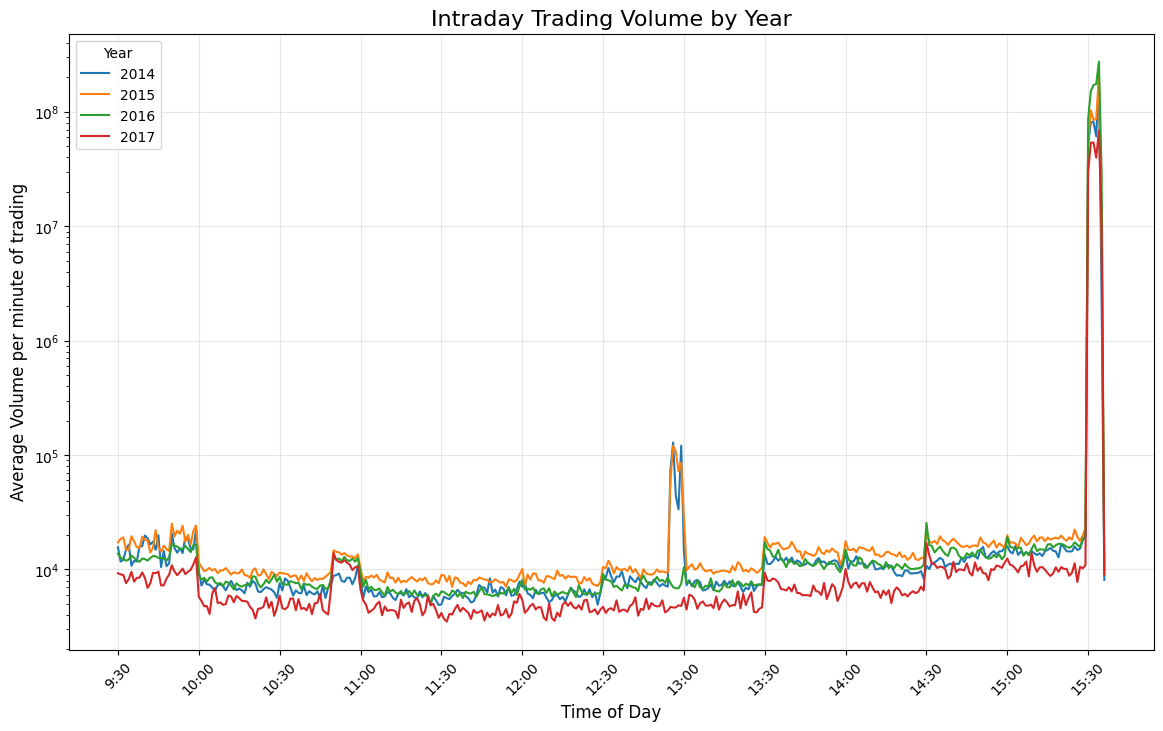

In [11]:
plt.figure(figsize=(14, 8))
for year in years:
    plt.plot(avg_volume.index, avg_volume[year], label=year)
plt.title('Intraday Trading Volume by Year', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Average Volume per minute of trading', fontsize=12)
plt.yscale('log')
plt.legend(title='Year')
plt.xticks(np.arange(0, len(times), 30), rotation=45)  # Show label every 30 minutes
plt.grid(True, alpha=0.3)
plt.show()

Okay but the trades that occur at the end of each day have such high volumes that we can't really analyse the rest.
Let's filter these last 7 minutes of trading.

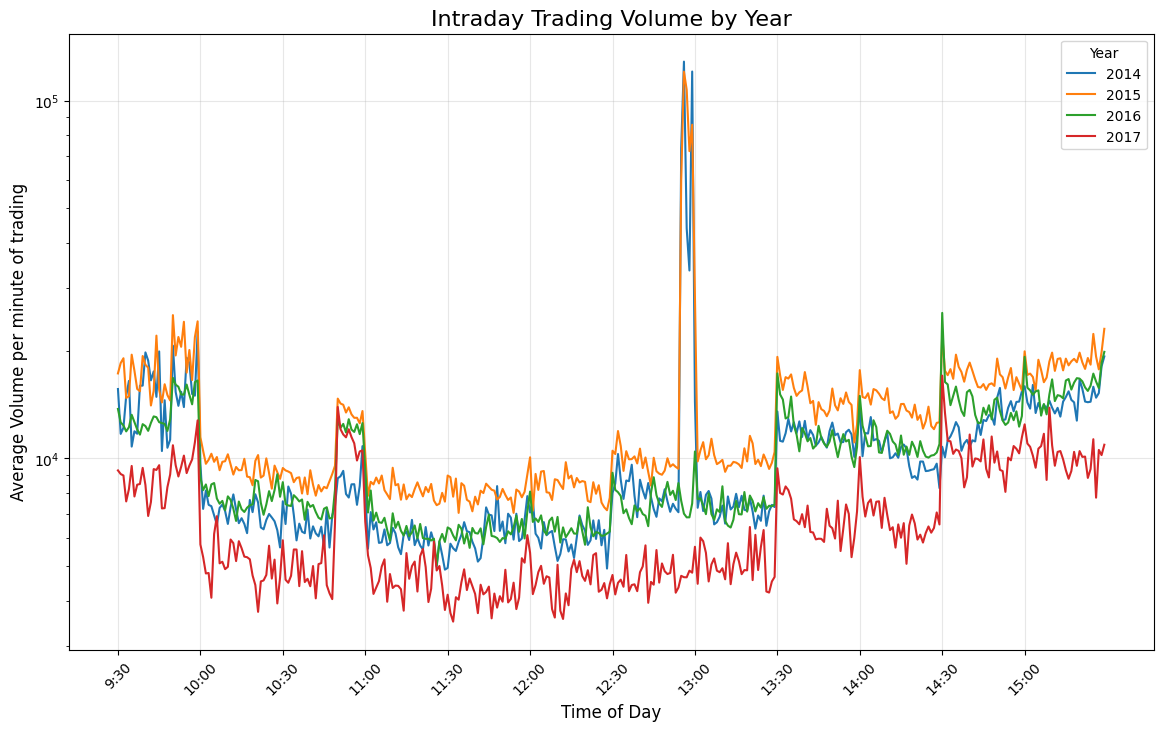

In [12]:
troncated_times = times[:-7]  # Exclude the last 7 minutes of the trading day
troncated_avg_volume = avg_volume.iloc[:-7]

plt.figure(figsize=(14, 8))
for year in years:
    plt.plot(troncated_avg_volume.index, troncated_avg_volume[year], label=year)
plt.title('Intraday Trading Volume by Year', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Average Volume per minute of trading', fontsize=12)
plt.yscale('log')
plt.legend(title='Year')
plt.xticks(np.arange(0, len(troncated_times), 30), rotation=45)  # Show label every 30 minutes
plt.grid(True, alpha=0.3)
plt.show()